# Notebook 02: Modeling

---

## Objective:

Build an end-to-end machine learning model to predict the number of calories an adult burns during a workout.

---

## Data Source

> Reade, W., & Park, E. (2025). *Predict Calorie Expenditure*. Kaggle.  
> https://kaggle.com/competitions/playground-series-s5e5

---

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Train-Test Data](#2-load-train-test-data)
3. [Define Pipelines](#3-define-pipelines)
   - 3.1 [Ridge Pipeline](#31-ridge-pipeline)
   - 3.2 [Tree Pipeline](#32-tree-pipeline)
   - 3.3 [XGBoost Pipeline](#33-xgboost-pipeline)   
4. [Baseline Model Comparison](#4-baseline-model-comparison)   
   - 4.1 [Cross-Validated RMSLE (3-Fold)](#41-cross-validated-rmsle-3-fold)
   - 4.2 [Results & Model Selection](#42-results--model-selection)
5. [Hyperparameter Tuning](#5-hyperparameter-tuning)
   - 5.1 [Search Strategy](#51-search-strategy)
   - 5.2 [Cross-Validated Results](#52-cross-validated-results)
   - 5.3 [Best Hyperparameters](#53-best-hyperparameters)
6. [Final Model Evaluation](#6-final-model-evaluation)
   - 6.1 [Calculate RMSLE Metric](#61-calculate-rmsle-metric)
   - 6.2 [SHAP Feature Importance](#63-shap-feature-importance)
7. [Kaggle Submission](#7-kaggle-submission)
8. [Save Model](#8-save-model)
9. [Discussion & Next Steps](#9-discussion-&-next-steps)
   - 9.1 [Model Assumptions](#91-model-assumptions)
   - 9.2 [Potential Data Leakage](#92-potential-data-leakage)
   - 9.3 [Model Improvements](#93-model-improvements)
   - 9.4 [Production Considerations](#94-production-considerations)


## 1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import (cross_validate, 
                                     RandomizedSearchCV,
                                     KFold)
from sklearn.metrics import root_mean_squared_log_error

from sklearn.linear_model import Ridge 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor

import shap

import joblib

import sys
import os
from tqdm.notebook import tqdm

# Add parent directory to path to access 'src' folder
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from src.feature_engineering import FeatureEngineering

# Set random seed for reproducibility
RANDOM_STATE = 42

## 2. Load Train-Test Data

In [2]:
# Set file paths
TRAIN_PATH = "../data/train_split.csv"
TEST_PATH = "../data/test_split.csv"

# Read split data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Display basic info on train
num_train_instances = train_df.shape[0]
print(f"Training set loaded with {num_train_instances:,} rows and {train_df.shape[1]} columns.")
train_df.head()

Training set loaded with 597,727 rows and 8 columns.


,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,53,189.0,85.0,22.0,100.0,40.5,142.0
1,female,51,171.0,71.0,12.0,90.0,39.7,56.0
2,female,69,155.0,60.0,16.0,92.0,40.6,86.0
3,female,57,161.0,62.0,21.0,100.0,40.8,127.0
4,male,61,183.0,83.0,6.0,87.0,39.1,25.0


In [3]:
# Separate features and target variable
X_train, y_train = train_df.drop("Calories", axis=1), train_df["Calories"]
X_test, y_test = test_df.drop("Calories", axis=1), test_df["Calories"]

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (597727, 7)
Training target shape: (597727,)
Testing features shape: (149432, 7)
Testing target shape: (149432,)


## 3. Define Pipelines

In [4]:
# Separate numeric and categorical features
NUMERIC_FEATURES = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "BMI", "BMR", "Duration_X_HR"]
CATEGORICAL_FEATURES = ["Sex"]
RIDGE_NUMERIC_FEATURES = ["Age", "Duration", "Heart_Rate", "Body_Temp", "BMI", "BMR", "Duration_X_HR"]

### 3.1 Ridge Pipeline

In [5]:
# Create preprocessing for Ridge regression model
ridge_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            # Impute missing numeric values with median
            ("impute", SimpleImputer(strategy="median")),
            # Scale numeric features for Ridge regression
            ("scale", StandardScaler())
        ]), RIDGE_NUMERIC_FEATURES),
        ("cat", Pipeline([
            # Impute missing categorical values with most frequent
            ("impute", SimpleImputer(strategy="most_frequent")),
            # One-hot encode categorical features, dropping the first category to avoid multicollinearity
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ],
    remainder="drop"
)

# Build Ridge regression pipeline
def build_ridge_pipeline(model):
    return Pipeline([
        # Add feature engineering step
        ("feature_engineering", FeatureEngineering()),
        # Add preprocessing
        ("preprocessing", ridge_preprocessor),
        # Add model
        ("model", model)
    ])

### 3.2 Tree Pipeline

In [6]:
# Create preprocessing for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        # Impute missing numeric values with median
        ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        ("cat", Pipeline([
            # Impute missing cateogrical values with most frequent
            ("impute", SimpleImputer(strategy="most_frequent")),
            # One-hot encode categorical features
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ],
    remainder="drop"
)

# Build tree-based model pipeline
def build_tree_pipeline(model):
    return Pipeline([
        # Add feature engineering step
        ("feature_engineering", FeatureEngineering()),
        # Add preprocessing
        ("preprocessing", tree_preprocessor),
        # Add model
        ("model", model)
    ])

### 3.3 XGBoost Pipeline

In [7]:
# Create preprocessing for XGBoost model
xgb_preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode categorical features
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder="passthrough"
)

# Build XGBoost model pipeline
def build_xgb_pipeline(model):
    return Pipeline([
        # Add feature engineering step
        ("feature_engineering", FeatureEngineering()),
        # Add preprocessing
        ("preprocessing", xgb_preprocessor),
        # Add model
        ("model", model)
    ])

## 4. Baseline Model Comparison

### 4.1 Cross-Validated RMSLE (3-Fold)

In [8]:
# Define base models with pipelines
base_models = {
    "Ridge": build_ridge_pipeline(Ridge(random_state=RANDOM_STATE)),
    "Decision Tree": build_tree_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10, min_samples_leaf=20)),
    "Random Forest": build_tree_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, max_depth=10, min_samples_leaf=20, n_estimators=100)),
    "XGBoost": build_xgb_pipeline(XGBRegressor(random_state=RANDOM_STATE, tree_method="hist"))
}

# Wrap base models with TransformedTargetRegressor to log-transform Calories for RMSLE evaluation
rmsle_models = {
    name: TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    ) for name, model in base_models.items()
}

In [9]:
# Create dictionary to store baseline metrics
baseline_metrics = {}

# Define cross-validation strategy
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Evaluate each model using cross-validation and store RMSLE metrics
for name, model in tqdm(rmsle_models.items()):
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring="neg_root_mean_squared_log_error",
        n_jobs=-1,
        return_train_score=True
    )

    # Store metrics in baseline_metrics dictionary
    baseline_metrics[name] = {
        "cv_test_rmsle_mean": -cv_results["test_score"].mean(),
        "cv_rmsle_std": cv_results["test_score"].std(),
        "cv_train_rmsle_mean": -cv_results["train_score"].mean(),  
        "cv_fit_time_mean": cv_results["fit_time"].mean(),
    }

  0%|          | 0/4 [00:00<?, ?it/s]

### 4.2 Results & Model Selection

In [10]:
# Show baseline metrics in a pandas DataFrame
baseline_results_df = (
    pd.DataFrame(baseline_metrics).T
    .rename_axis("model")
    .reset_index()
    .sort_values("cv_test_rmsle_mean")
    .assign(overfit_gap=lambda df: df["cv_test_rmsle_mean"] - df["cv_train_rmsle_mean"])
    .round(4)
    .reset_index(drop=True)  
)

print("Baseline Model Performance:")
baseline_results_df

Baseline Model Performance:


,model,cv_test_rmsle_mean,cv_rmsle_std,cv_train_rmsle_mean,cv_fit_time_mean,overfit_gap
0,XGBoost,0.0621,0.0003,0.0572,1.8491,0.0049
1,Random Forest,0.0703,0.0001,0.0684,67.0473,0.0019
2,Decision Tree,0.0769,0.0004,0.0747,1.3758,0.0022
3,Ridge,0.1504,0.0002,0.1504,0.3893,0.0000


XGBoost achieves the lowest cross-validated RMSLE (0.0621), outperforming Random Forest, Decision Tree, and Ridge regression. 

A large performance gap exists between Ridge and tree-based models which suggests that the relationship between calories burned and physiological features are strongly nonlinear. This is also suggested by some of the scatter plots present in the *eda-notebook-01*. 

While XGBoost does exhibit a slightly larger train-test performance gap (0.0049) compared to Random Forest and Decision Tree, the magnitude of the gap is relatively small and acceptable generalization performance. 

Additionally, XGBoost achieves a low mean fit time compared to Random Forest (over 1 minute), suggesting that it has better computational efficiency at scale. 

Given these details, XGBoost is selected for hyperparameter tuning.

## 5. Hyperparameter Tuning

### 5.1 Search Strategy

In [11]:
# Define hyperparameter distributions for XGBoost
param_dist = {
    "regressor__model__max_depth": stats.randint(4, 10),
    "regressor__model__learning_rate": stats.uniform(0.01, 0.29),
    "regressor__model__subsample": stats.uniform(0.6, 0.4),
    "regressor__model__colsample_bytree": stats.uniform(0.6, 0.4),
    "regressor__model__min_child_weight": stats.randint(1, 6),
    "regressor__model__n_estimators": stats.randint(300, 900),
}

# Define cross-validation strategy
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Set up RandomizedSearchCV for XGBoost
random_search = RandomizedSearchCV(
    rmsle_models["XGBoost"],
    param_distributions=param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring="neg_root_mean_squared_log_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    random_state=RANDOM_STATE
)

Early stopping was omitted during CV tuning due to integration complexity with RandomizedSearchCV, a large train size and conservative learning rate mitigate overfitting risk.

In [12]:
# Apply hyperparameter tuning with RandomizedSearchCV
random_search.fit(X_train, y_train);

Fitting 3 folds for each of 20 candidates, totalling 60 fits


### 5.2 Cross-Validated Results

In [13]:
# Extract hyperparameter values
param_cols = [c for c in pd.DataFrame(random_search.cv_results_).columns if c.startswith("param_")]

xgb_cv_results = (
    pd.DataFrame(random_search.cv_results_)
    .assign(
        mean_test_rmsle=lambda df: -df["mean_test_score"],
        mean_train_rmsle=lambda df: -df["mean_train_score"],
        overfit_gap=lambda df: -df["mean_test_score"] - (-df["mean_train_score"]),
        std_test_rmsle=lambda df: df["std_test_score"]
    ).sort_values("mean_test_rmsle")[["mean_test_rmsle", "mean_train_rmsle", "overfit_gap", "std_test_rmsle"] + param_cols]
    .round(4)
    .reset_index(drop=True)
)

xgb_cv_results.head(5)

,mean_test_rmsle,mean_train_rmsle,overfit_gap,std_test_rmsle,param_regressor__model__colsample_bytree,param_regressor__model__learning_rate,param_regressor__model__max_depth,param_regressor__model__min_child_weight,param_regressor__model__n_estimators,param_regressor__model__subsample
0,0.0601,0.0550,0.0051,0.0002,0.6624,0.0268,8,4,430,0.6082
1,0.0601,0.0546,0.0055,0.0004,0.7599,0.0235,7,3,866,0.9933
2,0.0606,0.0582,0.0024,0.0003,0.6795,0.0116,6,3,892,0.8845
3,0.0610,0.0479,0.0130,0.0004,0.8782,0.0504,8,3,840,0.6915
4,0.0610,0.0523,0.0087,0.0005,0.8737,0.1376,7,5,334,0.9637


### 5.3 Best Hyperparameters

In [14]:
print("Best hyperparameters found:")
print(random_search.best_params_)

Best hyperparameters found:
{'regressor__model__colsample_bytree': np.float64(0.662397808134481), 'regressor__model__learning_rate': np.float64(0.026844247528777843), 'regressor__model__max_depth': 8, 'regressor__model__min_child_weight': 4, 'regressor__model__n_estimators': 430, 'regressor__model__subsample': np.float64(0.608233797718321)}


## 6. Final Model Evaluation

In [15]:
# Extract best hyperparameters
best_params = {
    k.replace("regressor__model__", ""): v
    for k, v in random_search.best_params_.items()
}

# Build final XGBoost model with best hyperparameters
best_xgb_model = build_xgb_pipeline(
    XGBRegressor(
        **best_params,
        tree_method="hist",
        random_state=RANDOM_STATE
    )
)

# Wrap best XGBoost model with TransformedTargetRegressor for log-transforming target variable
final_model = TransformedTargetRegressor(
    regressor=best_xgb_model,
    func=np.log1p,
    inverse_func=np.expm1
)

In [16]:
# Fit on full training data
final_model.fit(X_train, y_train);

### 6.1 Calculate RMSLE Metric

In [17]:
# Evaluate final model on test set
y_pred = final_model.predict(X_test)
test_rmsle = root_mean_squared_log_error(y_test, y_pred)
print(f"Final XGBoost model RMSLE on test set: {test_rmsle:.4f}")

Final XGBoost model RMSLE on test set: 0.0602


### 6.2 SHAP Feature Importance

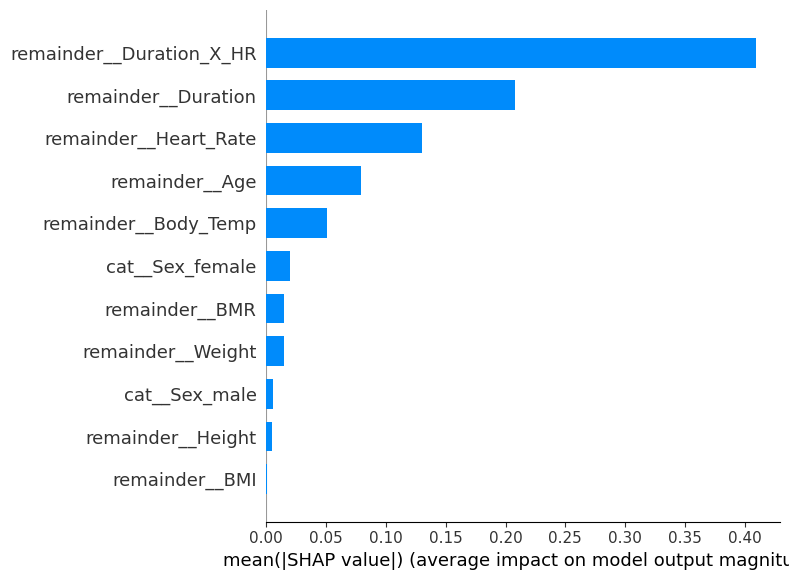

In [18]:
# Extract fitted XGBoost model
fitted_pipeline = final_model.regressor_
xgb_model = fitted_pipeline.named_steps["model"] 

# Transform test data using fitted preprocessing steps
fe = fitted_pipeline.named_steps["feature_engineering"] 
preprocessing = fitted_pipeline.named_steps["preprocessing"]

X_test_fe = fe.transform(X_test) 
X_test_preprocessed = preprocessing.transform(X_test_fe)

feature_names = preprocessing.get_feature_names_out()

# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_preprocessed)

# Plot SHAP summary plot
shap.summary_plot(
    shap_values,
    feature_names=feature_names,
    plot_type="bar"
)

`Key Drivers of Calories Burned`:

To gauge feature importance, SHAP (mean absolute value) is applied to the XGBoost model. SHAP helps quantify how significant each predictor is by measuring its contribution towards a prediciton. Features that are more influential have a higher mean absolute SHAP value. According to SHAP, the most important feature is the engineered interaction term, Duration_X_HR. These SHAP values explain contributions in log-calorie space due to the log1p transformation applied to the target.


## 7. Kaggle Submission

In [19]:
# Get kaggle test set path
KAGGLE_TEST_PATH = "../data/original/test.csv"

# Read kaggle test set
kaggle_test_df = pd.read_csv(KAGGLE_TEST_PATH)

# Predict on kaggle test set
kaggle_test_preds = final_model.predict(kaggle_test_df.drop("id", axis=1))

# Create submission DataFrame
submission_df = pd.DataFrame({
    "id": kaggle_test_df["id"],
    "Calories": kaggle_test_preds
})

submission_df.head()

,id,Calories
0,750000,27.335880
1,750001,108.235199
2,750002,87.495750
3,750003,126.709679
4,750004,75.966843


In [20]:
# Save submission file
submission_df.to_csv("../data/submission.csv", index=False)
print("Submission file saved.")

Submission file saved.


## 8. Save Model

In [21]:
joblib.dump(final_model, "../model/xgb_calories_model.joblib")
print("Model saved.")

Model saved.


## 9. Discussion & Next Steps

Calories burned are strictly positive and moderately right-skewed. RMSLE is the primary evaluation metric for the following reasons:

- It penalizes relative errors 
- It reduces sensitivity to extreme outliers
- It is selected by Kaggle as the performance metric

The results indicate that tree-based ensemble models substantially outperform linear models, indicating that nonlinear relationships are feature interactions are present.

### 9.1 Model Assumptions

- Ridge regression model assumptions
- Tree-based model assumptions
- Data assumptions
  
**Ridge Regression**

* Linearity
    * A linear relationship exists between predictors and the log-transformed target.
* Independent observations   
    * Each observation is taken from unique individuals and are independent.
* Homoscedastic residuals
    * Error has constant variance across levels of the predictors.
* Limited multicollinearity (mitigated with L2 regularization)

**Tree-based Assumptions**:   
Tree-based models do not make assumptions about the data or its underlying distribution so they are a type of non-parametric model.

**Data Assumptions**:   
Assumptions about the data include:
* Accurate and consistent measurement units:
    * `Duration` (minutes)
    * `Heart_Rate` (beats per minute)
    * `Height` (cm)
    * `Weight` (kg)
    * `Age` (years)
* Observations represent independent workout sessions.

### 9.2 Potential Data Leakage

- Engineered features such as **Duration_X_HR** were calculated from input features and not derived from the target variable.
- All preprocessing and feature engineering steps were performed inside the pipeline to ensure transformations were fit only on train during cross-validation.
- The final model was evaluated on a fully held-out test set that was not used for tuning.

These safeguards help mitigate any risk of target leakage.  


### 9.3 Model Improvements
  
- Incorporating additional physiological variables and behavior (activity type, diet, etc.)
- Exploring additonal ensemble models by stacking XGBoost and Random Forest
- Exploring additional nonlinear transformations to calculate proxies for workout intensity

### 9.4 Production Considerations    

If the final model is deployed in a real-world system (like a fitness tracking application) the following are considerations that may apply:

- Model Monitoring: Monitoring prediction drift as user population changes
- Data Drift: Tracking distribution shift in critical features
- Latency: XGBoost provides fast inference and computational scaling

---

## Summary 

XGBoost achieved the lowest cross-validated RMSLE (0.0621), outperforming Random Forest (0.0703), Decision Tree (0.0769), and Ridge regression (0.1504).

The performance of tree-based models suggests that caloric expenditure is governed by nonlinear relationships and feature interactions, particularly between workout duration and heart rate. SHAP analysis also reveals that engineered Duration x Hear Rate interaction was the most influential feature.

Future improvements may include additional physiological features.

---
